In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [9]:
# Load the dataset
file_path = './Data/Salary_Data_Based_country_and_race.csv'
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,0,32,Male,Bachelor's,Software Engineer,5.0,90000,UK,White
1,1,28,Female,Master's,Data Analyst,3.0,65000,USA,Hispanic
2,2,45,Male,PhD,Senior Manager,15.0,150000,Canada,White
3,3,36,Female,Bachelor's,Sales Associate,7.0,60000,USA,Hispanic
4,4,52,Male,Master's,Director,20.0,200000,USA,Asian


In [3]:
df["Gender"].value_counts()

Gender
Male      3672
Female    3013
Other       14
Name: count, dtype: int64

In [4]:
# One-hot encode the 'Gender' column
encoder = OneHotEncoder(sparse_output=False)
gender_encoded = encoder.fit_transform(df[['Gender']])

In [13]:
# Add the encoded gender back to the dataframe
for i, col in enumerate(encoder.categories_[0]):
    df[col + '_encoded'] = gender_encoded[:, i]
df.head()

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Female_encoded,Male_encoded,Other_encoded
0,0,32,Male,Bachelor's,Software Engineer,5.0,90000,UK,White,0.0,1.0,0.0
1,1,28,Female,Master's,Data Analyst,3.0,65000,USA,Hispanic,1.0,0.0,0.0
2,2,45,Male,PhD,Senior Manager,15.0,150000,Canada,White,0.0,1.0,0.0
3,3,36,Female,Bachelor's,Sales Associate,7.0,60000,USA,Hispanic,1.0,0.0,0.0
4,4,52,Male,Master's,Director,20.0,200000,USA,Asian,0.0,1.0,0.0


In [6]:
# Select 'Salary' as feature and 'Female_encoded' as the target
X = df[['Salary']]
y = df['Female_encoded']

In [7]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data preparation and encoding complete.')


model = SVC()
model.fit(X_train, y_train)

Data preparation and encoding complete.


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Training accuracy: 0.58
Test accuracy: 0.59

Confusion Matrix:
[[674  59]
 [490 117]]


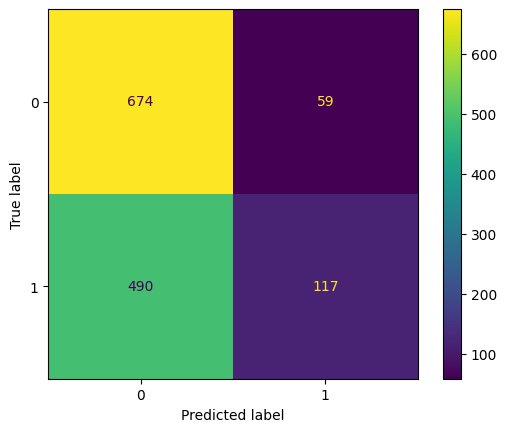

In [8]:
# Evaluate the model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Training accuracy: {train_score:.2f}')
print(f'Test accuracy: {test_score:.2f}')

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()